# TSM Scorecard

Runs the queries in `tsm_scorecard.sql` and computes the CS scorecard.

- **Cell 1** — raw scorecard output (per-company, YTD through end of last full quarter)
- **Cell 2** — per-deal expansions / renewals (won, non-zero net new ARR)
- **Cell 3** — scorecard aggregations (TBD)

In [1]:
import os
import pandas as pd
import snowflake.connector
from io import StringIO
from snowflake.connector.util_text import split_statements

conn = snowflake.connector.connect(
    connection_name=os.getenv("SNOWFLAKE_CONNECTION_NAME", "port-analytics-prod")
)
print(f"Connected as {conn.user} / role={conn.role} / db={conn.database}")

def run_query(sql: str) -> pd.DataFrame:
    cur = conn.cursor()
    try:
        cur.execute(sql)
        return cur.fetch_pandas_all()
    finally:
        cur.close()

# Use Snowflake's own SQL splitter so semicolons inside `-- ...` comments
# don't truncate statements.
with open("tsm_scorecard.sql") as f:
    _stmts = [s.strip() for s, _ in split_statements(StringIO(f.read()))]
SQL_SCORECARD  = _stmts[0]
SQL_EXPANSIONS = _stmts[1]
print(f"Loaded {len(_stmts)} statements from tsm_scorecard.sql")
print(f"  [0] scorecard  ({len(SQL_SCORECARD):,} chars)")
print(f"  [1] expansions ({len(SQL_EXPANSIONS):,} chars)")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://sso.jumpcloud.com/saml2/psf?SAMLRequest=nZJPc9owEMW%2Fikc925ZNSxMNkDEQJu4QcMFhJr10FEsQNbLkaKU44dNX5s9MekgOvXnk9%2Fa3u28HV6%2B1DF64AaHVECURRgFXlWZC7YborpyFFygASxWjUis%2BRG8c0NVoALSWDcmcfVQr%2Fuw42MAXUkC6H0PkjCKaggCiaM2B2Iqss9s5SSNMKAA31uPQycJAeNajtQ2J47Zto7YXabOLU4xxjC9jr%2BokX9A7RPM5ozHa6krLs%2BXVz%2FQBIonx1w7hFZ5QnIxjoY4r%2BIzycBQBuSnLIiyW6xIF2Xm6iVbgam7W3LyIit%2Bt5scGwHdQ%2FNiMl%2Btrb1mVv7NFNr8v88k6AqXbraRPvNJ146wvHfmveMtZLPVO%2BIXl0yFqngTbS%2BoY9CbJ856mfT5esM3%2BZ5Hd57NeuUzdzdzC9YYmD2Z2W6Fgc4437eLNARzPVReq9U847Yf4Iky%2Fl0mfYEzwZZR86%2F9CwdSHKhS1B%2Be5cwAd%2FXF1U0nt2KG7Lo00bmCLjldBDvXN6L9mHcTvS5yubOEXn08LLUX1Fsy0qan9OJckSg4vgoXbg5TwmgqZMWY4gM9HSt1ODKfWH7M1jqN4dKT%2Be86jvw%3D%3D&RelayState=ver%3A3-hint%3A5187783636193286-ETMsDgAAAaBD8zvEABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEDA6t8NgxuKr%2BBhEQ%2BXSTpEAAACg8J4hUn9aYWYbmOes8RTsgELVupERw3s7NyZQVyp4A237%2BRT5DbJ%2FCzC3tey0g3zG

 pip install snowflake-connector-python[secure-local-storage]


## Cell 1 — Scorecard raw data

Per-company row set covering ownership, tier, ARR, licence lifecycle, engagement (Gong / building signals / actions / seat utilization), renewal indicators, etc. Attribution is by current owner unless noted.

In [2]:
df_scorecard = run_query(SQL_SCORECARD)
print(f"{len(df_scorecard):,} rows × {len(df_scorecard.columns)} columns")
df_scorecard

200 rows × 49 columns


,AM_OWNER,AM_OWNER_JAN1,AM_ASSIGN_DATE,AM_HIRE_DATE,AM_DEPARTMENT,AM_AGE_DAYS,AM_RAMP_UP_PCT,CS_OWNER,CS_OWNER_JAN1,CS_ASSIGN_DATE,...,CS_GONG_CALLS,AM_GONG_CALLS,ONBOARDING_COMPLETED_DATE,FIRST_LICENCE_START,CUSTOMER_AGE_MONTHS,LATEST_RENEWAL_DATE,LICENCE_START_CURRENT_Y,LICENCE_END,RENEWAL_DATE_YTD_TO_FULL_LAST_Q,DID_RENEW
0,Jeff Graham,Jeff Graham,2022-11-20,2024-07-29,Sales,521.0,100.0,German Martinez,German Martinez,2025-10-17,...,13,14,None,2025-10-01,8.0,2028-09-30,None,None,None,NaN
1,Evan Smith,Sam Neill,2026-04-07,2026-01-26,Sales,NaN,None,Sam Bettencourt,Chris Hodson,2026-07-01,...,8,27,2022-11-02,2025-01-01,17.0,2029-06-30,2026-01-01,2026-12-31,None,1.0
2,Rick Walker,Tom Skarzynski,2026-02-08,2026-01-26,Sales,NaN,None,Raz Chen,Magali Philippe,2026-02-24,...,20,28,2022-11-02,2024-10-01,20.0,2027-09-30,None,None,None,NaN
3,Andrew Johnston,Tali Cohen,2026-05-07,2026-04-07,Sales,NaN,None,German Martinez,Al Sharma,2026-01-08,...,2,3,None,2026-01-01,5.0,2028-12-31,2026-01-01,2026-12-31,2026-01-01,NaN
4,Evan Smith,Sam Neill,2026-04-27,2026-01-26,Sales,NaN,None,Kavita Pant,Kavita Pant,2025-11-04,...,30,28,2022-12-13,2024-05-20,25.0,2027-05-19,2026-05-20,2027-05-19,None,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Ignacio De Loera,Sam Neill,2026-02-19,2026-01-12,Sales,NaN,None,NaN,NaN,2025-10-28,...,0,0,None,None,NaN,None,None,None,2026-05-01,NaN
196,Omri Gilad,Sharon Peretz,2026-02-11,2024-07-01,Sales,549.0,100.0,NaN,NaN,2022-10-30,...,0,2,None,2026-02-12,4.0,2027-02-11,2026-02-12,2027-02-11,2026-02-12,NaN
197,Omri Gilad,Omri Gilad,2025-12-31,2024-07-01,Sales,549.0,100.0,NaN,NaN,2024-05-14,...,0,0,None,2024-11-15,19.0,2027-11-14,None,None,None,NaN
198,Omri Gilad,Omri Gilad,2025-12-31,2024-07-01,Sales,549.0,100.0,NaN,NaN,2025-04-29,...,0,1,2022-08-18,2023-01-10,41.0,2030-01-09,2026-01-10,2027-01-09,None,1.0


## Cell 2 — CW Expansions / Renewals per deal

One row per won `Expansion` or `existingbusiness` deal closed between Jan 1 and end of last full quarter, with `DEAL_NET_NEW_ARR != 0`. Owner attribution is SCD-at-deal-close-time.

In [3]:
df_deals = run_query(SQL_EXPANSIONS)
print(f"{len(df_deals):,} deals, total NET_NEW_ARR = ${df_deals['NET_NEW_ARR'].sum():,.2f}")
df_deals

33 deals, total NET_NEW_ARR = $3,448,218.00


,COMPANY_CRM_ID,COMPANY_NAME,TIER,DEAL_TYPE,CS_OWNER,AM_OWNER,DEAL_CLOSED_DATE,NET_NEW_ARR,LICENSE_END_DATE,DAYS_BEFORE_RENEWAL
0,57526618144,PwC,Strategic,Expansion,Sam Bettencourt,Evan Smith,2026-06-26,2000000.0,2029-06-30,1100
1,15229057330,maya ph,Core,existingbusiness,Azeez Ibrahim Akinkunmi,Omri Gilad,2026-06-26,137509.0,2028-08-08,774
2,50870720180,Merck,Core+,existingbusiness,NaN,Omri Gilad,2026-04-30,135804.0,2028-12-31,976
3,51855126337,World Bank,Core+,existingbusiness,German Martinez,Chris Sweeney,2026-05-20,134548.0,2027-06-22,398
4,47966501454,bhp,Core,existingbusiness,Uday Korlimarla,Scott Dunion,2026-03-10,129275.0,2027-06-29,476
5,39561079636,Banco de Chile,Strategic,existingbusiness,Mariela Moreno,Ignacio De Loera,2026-03-31,120000.0,2027-04-30,395
6,34916448068,qodo,Digital,existingbusiness,NaN,Omri Gilad,2026-03-29,100520.0,2027-06-30,458
7,37512264292,Legal and General,Core+,Expansion,Lee Silberstein,Benjamin Duckworth,2026-03-27,83840.0,2027-11-24,607
8,10077102108,smarsh,Core,Expansion,Uday Korlimarla,Omri Gilad,2026-03-19,74250.0,2026-12-31,287
9,55478622843,"everest global services, inc.",Core+,existingbusiness,Kavita Pant,John Romano,2026-03-26,69096.0,2027-05-31,431


## Targets

Per-metric goals used to evaluate each CS owner's aggregated scorecard.
- Percentages are expressed as decimals (0.95 = 95%).
- **Time-to-Onboarding** targets are 0 by default (no lag) — set to whatever SLA you want.
- **Gong meetings** is a per-customer-per-quarter target, so the owner's overall target scales with their customer count.
- **CW Expansion** is a composite score: `(Expansions × 40) + (Avg days_before_renewal / 10) + (Net New ARR / 25,000)`.

In [4]:
GONG_MEETINGS_PER_CUSTOMER_PER_QUARTER = 4  # 4 calls / customer / quarter

TARGETS = {
    'NRR':                        1.35,   # 135%
    'GRR':                        0.95,   # 95%
    'LOGO_RETENTION':             0.95,   # 95%
    'STRATEGIC_TIME_TO_ONBOARD':  0,      # days
    'CORE_PLUS_TIME_TO_ONBOARD':  0,      # days
    'CORE_TIME_TO_ONBOARD':       0,      # days
    'SEAT_UTILIZATION':           0.80,   # 80% share of customers meeting their tenure-based utilization threshold
    'AVG_ACTIONS_MOM':            0.75,   # 75% of MoM transitions non-decreased
    'AVG_BUILDING_SIGNALS':       2500,   # average per customer
}

# --- Dynamic targets (per owner, computed from their customer portfolio) ---
def gong_meetings_target(customer_quarters_active) -> float:
    """Owner-level Gong target = 4 calls per customer per quarter, prorated
    by how much of the measurement window each customer was active.

    `customer_quarters_active` is an iterable of per-customer values, each
    representing 'quarters of the measurement window this customer was
    active for' (e.g. a customer active for all 2 quarters YTD contributes
    2.0; one active for only half of Q2 contributes 0.5). Sum × 4 is the
    owner's target call count."""
    return GONG_MEETINGS_PER_CUSTOMER_PER_QUARTER * sum(customer_quarters_active)

def cw_expansion_score(expansion_logos: int, avg_days_before_renewal: float, net_new_arr: float) -> float:
    if not expansion_logos:
        return 0.0
    return (avg_days_before_renewal * net_new_arr) / (expansion_logos * 2_000_000)

# --- Pretty-print --------------------------------------------------------
import pandas as pd

_FMT = {
    'NRR':                        ('Net Revenue Retention',              lambda v: f'{v:.0%}'),
    'GRR':                        ('Gross Revenue Retention',            lambda v: f'{v:.0%}'),
    'LOGO_RETENTION':             ('Logo Retention',                     lambda v: f'{v:.0%}'),
    'STRATEGIC_TIME_TO_ONBOARD':  ('Strategic — Time to Onboarding',    lambda v: f'{v} days'),
    'CORE_PLUS_TIME_TO_ONBOARD':  ('Core+ — Time to Onboarding',        lambda v: f'{v} days'),
    'CORE_TIME_TO_ONBOARD':       ('Core — Time to Onboarding',         lambda v: f'{v} days'),
    'SEAT_UTILIZATION':           ('Seat Utilization (customers meeting threshold)', lambda v: f'{v:.0%}'),
    'AVG_ACTIONS_MOM':            ('Actions MoM Growth',                 lambda v: f'{v:.0%}'),
    'AVG_BUILDING_SIGNALS':       ('Avg Building Signals',               lambda v: f'{v:,} / customer'),
}

_rows = [{'Metric': label, 'Target': fmt(TARGETS[k])} for k, (label, fmt) in _FMT.items()]
_rows.append({
    'Metric': 'Gong Meetings (dynamic)',
    'Target': f'{GONG_MEETINGS_PER_CUSTOMER_PER_QUARTER} calls / customer / quarter — owner target = 4 × Σ(customer_quarters_active)',
})
_rows.append({
    'Metric': 'CW Expansion (composite)',
    'Target': '(Avg days_before_renewal × Net New ARR) ÷ (Expansion logos × 2,000,000)',
})
print('CS Scorecard Targets')
print('=' * 90)
for r in _rows:
    print(f"  {r['Metric']:<50} {r['Target']}")
print('=' * 90)
pd.DataFrame(_rows).set_index('Metric')

CS Scorecard Targets
  Net Revenue Retention                              135%
  Gross Revenue Retention                            95%
  Logo Retention                                     95%
  Strategic — Time to Onboarding                     0 days
  Core+ — Time to Onboarding                         0 days
  Core — Time to Onboarding                          0 days
  Seat Utilization (customers meeting threshold)     80%
  Actions MoM Growth                                 75%
  Avg Building Signals                               2,500 / customer
  Gong Meetings (dynamic)                            4 calls / customer / quarter — owner target = 4 × Σ(customer_quarters_active)
  CW Expansion (composite)                           (Avg days_before_renewal × Net New ARR) ÷ (Expansion logos × 2,000,000)


,Target
Metric,
Net Revenue Retention,135%
Gross Revenue Retention,95%
Logo Retention,95%
Strategic — Time to Onboarding,0 days
Core+ — Time to Onboarding,0 days
Core — Time to Onboarding,0 days
Seat Utilization (customers meeting threshold),80%
Actions MoM Growth,75%
Avg Building Signals,"2,500 / customer"


## Weights

Each CS owner's overall score is a weighted average of their metric-vs-target attainment. Weights must sum to **100%**.

In [5]:
WEIGHTS = {
    'NRR':                        0.25,
    'GRR':                        0.25,
    'LOGO_RETENTION':             0.10,
    'STRATEGIC_TIME_TO_ONBOARD':  0.00,
    'CORE_PLUS_TIME_TO_ONBOARD':  0.00,
    'CORE_TIME_TO_ONBOARD':       0.00,
    'SEAT_UTILIZATION':           0.20,
    'GONG_MEETINGS'            : 0.10,
    'AVG_ACTIONS_MOM':            0.00,
    'AVG_BUILDING_SIGNALS':       0.00,
    'CW_EXPANSION':               0.10,
}

_total = round(sum(WEIGHTS.values()), 4)
print('CS Scorecard Weights')
print('=' * 60)
for k, v in WEIGHTS.items():
    marker = ' ' if v > 0 else 'x'
    print(f'  [{marker}] {k:<28} {v:.0%}')
print('-' * 60)
print(f'  {"TOTAL":<32} {_total:.0%}')
print('=' * 60)
if _total != 1.0:
    diff = (_total - 1.0)
    print()
    print(f'!!! ALERT: weights sum to {_total:.2%}, off by {diff:+.2%}. Adjust so total = 100%.')
else:
    print('OK - weights sum to 100%.')

import pandas as pd


CS Scorecard Weights
  [ ] NRR                          25%
  [ ] GRR                          25%
  [ ] LOGO_RETENTION               10%
  [x] STRATEGIC_TIME_TO_ONBOARD    0%
  [x] CORE_PLUS_TIME_TO_ONBOARD    0%
  [x] CORE_TIME_TO_ONBOARD         0%
  [ ] SEAT_UTILIZATION             20%
  [ ] GONG_MEETINGS                10%
  [x] AVG_ACTIONS_MOM              0%
  [x] AVG_BUILDING_SIGNALS         0%
  [ ] CW_EXPANSION                 10%
------------------------------------------------------------
  TOTAL                            100%
OK - weights sum to 100%.


## Cell 3 — CS Scorecard aggregations

TBD — aggregate `df_scorecard` (and `df_deals` where relevant) into per-CS-owner scorecards. Definition to be specified by user.

In [6]:
# Per-CS-owner scorecard.
# Aggregate df_scorecard, compute metrics, score = min(success_rate * weight, weight).

import pandas as pd
import numpy as np

df = df_scorecard[df_scorecard['CS_OWNER'].notna()].copy()

# Fallback if the Targets cell hasn't been run in this kernel session
_GONG_PER_CQ = globals().get('GONG_MEETINGS_PER_CUSTOMER_PER_QUARTER', 4)

# Tolerant weight lookup (handles either Gong weight key name across kernel states)
def _w(*keys, default=0.0):
    for k in keys:
        if k in WEIGHTS:
            return WEIGHTS[k]
    return default

# --- Per-customer quarters active (whole calendar months / 3) for Gong target ---
YEAR_START = pd.Timestamp(pd.Timestamp.today().year, 1, 1)
_q_start   = pd.Timestamp(pd.Timestamp.today()).to_period('Q').start_time
WINDOW_END = (_q_start - pd.Timedelta(days=1)).normalize()   # end of last full quarter

_first        = pd.to_datetime(df['FIRST_LICENCE_START'])
_window_start = _first.where(_first > YEAR_START, YEAR_START)
_months = ((WINDOW_END.year - _window_start.dt.year) * 12
           + (WINDOW_END.month - _window_start.dt.month) + 1).clip(lower=0)
df['_QUARTERS_ACTIVE'] = _months / 3.0     # full Jan-Jun window = 6/3 = 2.0

cs = (
    df.groupby('CS_OWNER', dropna=False)
      .agg(
          CS_HIRE_DATE          = ('CS_HIRE_DATE',           'first'),
          CS_RAMP_UP_PCT        = ('CS_RAMP_UP_PCT',         'first'),
          LOGOS                 = ('COMPANY_CRM_ID',         'count'),
          STRATEGIC             = ('IS_STRATEGIC',           'sum'),
          CORE_PLUS             = ('IS_CORE_PLUS',           'sum'),
          CORE                  = ('IS_CORE',                'sum'),
          DIGITAL               = ('IS_DIGITAL',             'sum'),
          ARR_START_OF_YEAR     = ('ARR_START_OF_YEAR',      'sum'),
          ARR_LAST_FULL_QUARTER = ('ARR_LAST_FULL_QUARTER',  'sum'),
          ARR_CHANGE            = ('ARR_CHANGE',             'sum'),
          ARR_RETAINED          = ('ARR_RETAINED',           'sum'),
          RETAINED_LOGOS        = ('IS_RETAINED',            'sum'),
          GONG_CALLS            = ('CS_GONG_CALLS',          'sum'),
          SEAT_UTIL_MEETS       = ('SEAT_UTIL_MEETS_TARGET', 'sum'),
          QUARTERS_ACTIVE       = ('_QUARTERS_ACTIVE',       'sum'),
          ACTIONS_MOM_PCT       = ('ACTIONS_MOM_PCT',        'mean'),   # skips NaN
          BUILDING_SIGNALS      = ('TOTAL_BUILDING_SIGNALS', 'mean'),   # skips NaN
          STRATEGIC_TTO         = ('STRATEGIC_TTO_DAYS',     'mean'),
          CORE_PLUS_TTO         = ('CORE_PLUS_TTO_DAYS',     'mean'),
          CORE_TTO              = ('CORE_TTO_DAYS',          'mean'),
      )
      .reset_index()
)

def score(success_rate, weight):
    return np.minimum(success_rate * weight, weight)

# NRR
cs['NRR']                       = cs['ARR_LAST_FULL_QUARTER'] / cs['ARR_START_OF_YEAR'].replace(0, np.nan)
cs['NRR_TARGET']                = TARGETS['NRR']
cs['NRR_SUCCESS_RATE']          = cs['NRR'] / cs['NRR_TARGET']
cs['NRR_SCORE']                 = score(cs['NRR_SUCCESS_RATE'], WEIGHTS['NRR'])

# GRR
cs['GRR']                       = cs['ARR_RETAINED'] / cs['ARR_START_OF_YEAR'].replace(0, np.nan)
cs['GRR_TARGET']                = TARGETS['GRR']
cs['GRR_SUCCESS_RATE']          = cs['GRR'] / cs['GRR_TARGET']
cs['GRR_SCORE']                 = score(cs['GRR_SUCCESS_RATE'], WEIGHTS['GRR'])

# Logo Retention
cs['LOGO_RETENTION']            = cs['RETAINED_LOGOS'] / cs['LOGOS'].replace(0, np.nan)
cs['LOGO_RETENTION_TARGET']     = TARGETS['LOGO_RETENTION']
cs['LOGO_RETENTION_SUCCESS_RATE'] = cs['LOGO_RETENTION'] / cs['LOGO_RETENTION_TARGET']
cs['LOGO_RETENTION_SCORE']      = score(cs['LOGO_RETENTION_SUCCESS_RATE'], WEIGHTS['LOGO_RETENTION'])

# Seat Utilization (share of customers meeting their tenure-based threshold)
cs['SEAT_UTILIZATION']              = cs['SEAT_UTIL_MEETS'] / cs['LOGOS'].replace(0, np.nan)
cs['SEAT_UTILIZATION_TARGET']       = TARGETS['SEAT_UTILIZATION']
cs['SEAT_UTILIZATION_SUCCESS_RATE'] = cs['SEAT_UTILIZATION'] / cs['SEAT_UTILIZATION_TARGET']
cs['SEAT_UTILIZATION_SCORE']        = score(cs['SEAT_UTILIZATION_SUCCESS_RATE'], WEIGHTS['SEAT_UTILIZATION'])

# Gong Meetings (dynamic target = 4 * quarters_active; symmetric success rate)
cs['GONG_ACTUAL_CALLS'] = cs['GONG_CALLS']
cs['GONG_TARGET_CALLS'] = _GONG_PER_CQ * cs['QUARTERS_ACTIVE']
_ratio = cs['GONG_ACTUAL_CALLS'] / cs['GONG_TARGET_CALLS'].replace(0, np.nan)
cs['GONG_SUCCESS_RATE'] = np.where(_ratio <= 1, _ratio, 1 / _ratio)   # peak at exact target
cs['GONG_SCORE']        = score(cs['GONG_SUCCESS_RATE'], _w('GONG_MEETINGS', 'GONG_MEETINGS_PER_CUSTOMER'))

# Actions MoM (ACTIONS_MOM_PCT is 0-100 -> scale to 0-1)
cs['ACTIONS_MOM']              = cs['ACTIONS_MOM_PCT'] / 100.0
cs['ACTIONS_MOM_TARGET']       = TARGETS['AVG_ACTIONS_MOM']
cs['ACTIONS_MOM_SUCCESS_RATE'] = cs['ACTIONS_MOM'] / cs['ACTIONS_MOM_TARGET']
cs['ACTIONS_MOM_SCORE']        = score(cs['ACTIONS_MOM_SUCCESS_RATE'], WEIGHTS['AVG_ACTIONS_MOM'])  # weight 0

# Avg Building Signals
cs['AVG_BUILDING_SIGNALS']              = cs['BUILDING_SIGNALS']
cs['AVG_BUILDING_SIGNALS_TARGET']       = TARGETS['AVG_BUILDING_SIGNALS']
cs['AVG_BUILDING_SIGNALS_SUCCESS_RATE'] = cs['AVG_BUILDING_SIGNALS'] / cs['AVG_BUILDING_SIGNALS_TARGET']
cs['AVG_BUILDING_SIGNALS_SCORE']        = score(cs['AVG_BUILDING_SIGNALS_SUCCESS_RATE'], WEIGHTS['AVG_BUILDING_SIGNALS'])  # weight 0

# Time to Onboarding (display only; weights are 0 so no score)
cs['STRATEGIC_TTO_DAYS'] = cs['STRATEGIC_TTO']
cs['CORE_PLUS_TTO_DAYS'] = cs['CORE_PLUS_TTO']
cs['CORE_TTO_DAYS']      = cs['CORE_TTO']

# CW Expansion / Renewal (from df_deals; attributed to close-time CS owner)
_exp = (
    df_deals[df_deals['CS_OWNER'].notna()]
      .groupby('CS_OWNER')
      .agg(
          CW_EXPANSION_ARR           = ('NET_NEW_ARR',        'sum'),
          CW_EXPANSION_LOGOS         = ('COMPANY_CRM_ID',     'nunique'),
          CW_AVG_DAYS_BEFORE_RENEWAL = ('DAYS_BEFORE_RENEWAL','mean'),
      )
      .reset_index()
)
cs = cs.merge(_exp, on='CS_OWNER', how='left')
cs['CW_EXPANSION_ARR']   = cs['CW_EXPANSION_ARR'].fillna(0)
cs['CW_EXPANSION_LOGOS'] = cs['CW_EXPANSION_LOGOS'].fillna(0)
# Score = (Avg days_before_renewal * Net New ARR) / (Expansion logos * 20,000)
_denom = (cs['CW_EXPANSION_LOGOS'] * 2_000_000).replace(0, np.nan)
cs['CW_EXPANSION_SCORE'] = (
    cs['CW_AVG_DAYS_BEFORE_RENEWAL'].fillna(0) * cs['CW_EXPANSION_ARR']
) / _denom
cs['CW_EXPANSION_SCORE'] = cs['CW_EXPANSION_SCORE'].fillna(0)   # owners with no expansion -> 0
cs['CW_EXPANSION_WEIGHTED_SCORE'] = np.minimum(
    cs['CW_EXPANSION_SCORE'] * _w('CW_EXPANSION'), _w('CW_EXPANSION'))

# Total weighted score
_score_cols = ['NRR_SCORE','GRR_SCORE','LOGO_RETENTION_SCORE',
               'SEAT_UTILIZATION_SCORE','GONG_SCORE',
               'ACTIONS_MOM_SCORE','AVG_BUILDING_SIGNALS_SCORE',
               'CW_EXPANSION_WEIGHTED_SCORE']
cs['TOTAL_SCORE'] = cs[_score_cols].sum(axis=1)

cs = cs.sort_values('TOTAL_SCORE', ascending=False).reset_index(drop=True)

cs

,CS_OWNER,CS_HIRE_DATE,CS_RAMP_UP_PCT,LOGOS,STRATEGIC,CORE_PLUS,CORE,DIGITAL,ARR_START_OF_YEAR,ARR_LAST_FULL_QUARTER,...,AVG_BUILDING_SIGNALS_SCORE,STRATEGIC_TTO_DAYS,CORE_PLUS_TTO_DAYS,CORE_TTO_DAYS,CW_EXPANSION_ARR,CW_EXPANSION_LOGOS,CW_AVG_DAYS_BEFORE_RENEWAL,CW_EXPANSION_SCORE,CW_EXPANSION_WEIGHTED_SCORE,TOTAL_SCORE
0,Mariela Moreno,2025-08-15,100.0,17,3,0,14,0,1784575.0,1931575.0,...,0.0,NaN,NaN,NaN,147000.0,2.0,380.000000,13.965000,0.1000,0.918289
1,Ayodeji Adeoti,2024-01-01,100.0,3,0,1,1,1,486820.0,499820.0,...,0.0,NaN,NaN,NaN,13000.0,1.0,380.000000,2.470000,0.1000,0.878548
2,German Martinez,2025-10-06,96.7,9,3,5,1,0,2169630.0,2373274.0,...,0.0,NaN,NaN,NaN,134548.0,1.0,398.000000,26.775052,0.1000,0.859453
3,Raz Chen,2025-07-14,100.0,17,1,4,12,0,1801967.0,1961546.0,...,0.0,NaN,NaN,NaN,100931.0,3.0,403.666667,6.790413,0.1000,0.850472
4,Sam Bettencourt,2025-09-29,100.0,13,2,2,9,0,2230000.0,4230000.0,...,0.0,NaN,NaN,NaN,2000000.0,1.0,1100.000000,1100.000000,0.1000,0.806581
5,Lee Silberstein,2025-05-25,100.0,11,0,1,10,0,1171170.0,1143570.0,...,0.0,NaN,NaN,NaN,109040.0,3.0,552.000000,10.031680,0.1000,0.804924
6,Kavita Pant,2025-10-20,81.1,12,2,2,8,0,1645346.0,1645491.0,...,0.0,NaN,NaN,NaN,69096.0,1.0,431.000000,14.890188,0.1000,0.760447
7,Azeez Ibrahim Akinkunmi,2025-07-08,100.0,11,0,2,8,1,830875.8,1180459.8,...,0.0,NaN,NaN,NaN,137509.0,1.0,774.000000,53.215983,0.1000,0.746608
8,Daniel Chupak,2026-01-22,None,1,0,0,1,0,122880.0,122880.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,0.000000,0.0000,0.735185
9,Sam Kohli,2026-06-02,None,9,0,4,5,0,1035455.0,1172935.0,...,0.0,NaN,NaN,NaN,18000.0,1.0,31.000000,0.279000,0.0279,0.646006


## How the scorecard works

Each CS owner is scored on several metrics, then the metric scores add up to one **Total score**.

**For every metric:**
1. **Actual** — roll up the owner's customers (or deals): a sum, an average, or a share.
2. **Success rate** = Actual ÷ Target — how close they got to goal.
3. **Score** = Success rate × the metric's weight, **capped at that weight**.

**Total score = sum of all metric scores** (max 100%). Metrics that don't apply score 0.

**Where the data comes from**
- Most metrics use the per-customer table (Cell 1), attributed to the customer's *current* CS owner.
- CW Expansion uses the per-deal table (Cell 2), attributed to the CS owner *at the deal's close date*.

**The metrics**
| Metric | Actual | Target |
| --- | --- | --- |
| NRR | Σ end-of-Q ARR ÷ Σ start-of-year ARR | 135% |
| GRR | same but each customer capped at their starting ARR (expansion can't mask churn) | 95% |
| Logo Retention | share of customers still active at quarter end | 95% |
| Seat Utilization | share of customers meeting their own usage bar (30/80/100% by tenure; unlimited always passes) | 80% |
| Gong Meetings | Σ calls vs 4 per customer per quarter (target grows with portfolio & customer tenure) | dynamic |
| Actions MoM | avg share of months where a customer's self-service runs didn't drop | 75% (weight 0) |
| Avg Building Signals | avg building signals per customer | 2,500 (weight 0) |
| Time to Onboarding | avg days to reach Evolution, per tier | shown only (weight 0) |
| CW Expansion | (Avg days_before_renewal × Net New ARR) ÷ (Expansion logos × 2,000,000) | score used directly |

**Good to know (the nuances)**
- **The cap means beating a target earns nothing extra** — you can reach a metric's weight but not exceed it. Wherever actual comfortably clears target, that metric effectively becomes pass/fail.
- **Gong is scored symmetrically:** hitting the target exactly is best; both under-calling and over-calling lose points equally.
- **Two owner attributions coexist:** every metric except CW credits the *current* owner; CW credits the *close-time* owner — so an owner can score on a deal they've since handed off, or miss one that closed before they arrived.
- **NULLs:** Actions MoM and Building Signals averages skip customers with no value; Seat Utilization counts a missing customer as *not passing*.
- **Weights must total 100%** (checked in the Weights cell). Metrics at 0% weight still compute for visibility but add nothing to the total.

## CS owners by total score

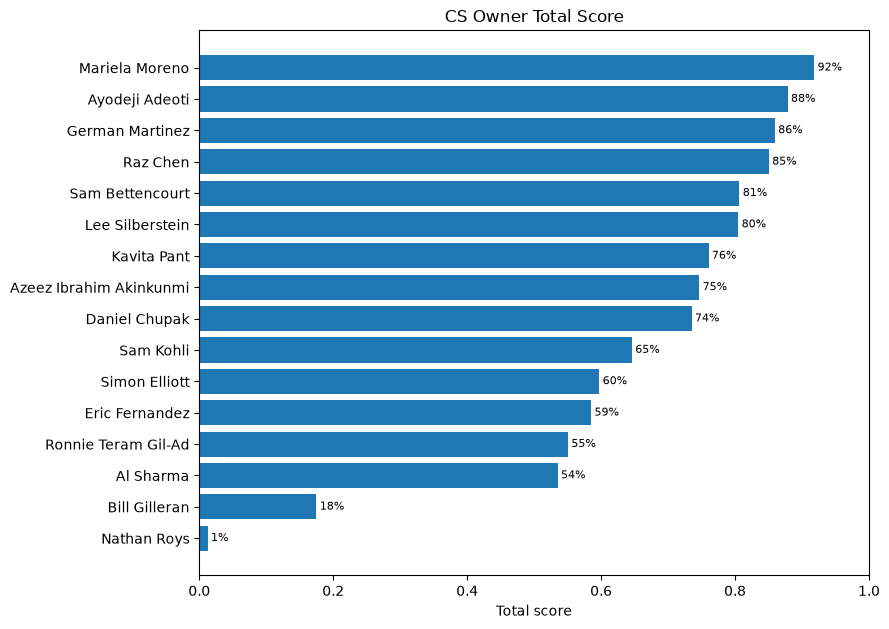

In [7]:
import matplotlib.pyplot as plt

_c = cs.sort_values('TOTAL_SCORE', ascending=True)   # ascending so largest lands on top in barh
fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(_c))))
ax.barh(_c['CS_OWNER'], _c['TOTAL_SCORE'])
ax.set_xlabel('Total score')
ax.set_xlim(0, 1)
ax.set_title('CS Owner Total Score')
for y, v in enumerate(_c['TOTAL_SCORE']):
    ax.text(v + 0.005, y, f'{v:.0%}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Success rate per metric

In [8]:
# Success rate per metric (actual / target). CW has no target-based rate; its raw score is shown separately.
_success_cols = ['NRR_SUCCESS_RATE','GRR_SUCCESS_RATE','LOGO_RETENTION_SUCCESS_RATE',
                 'SEAT_UTILIZATION_SUCCESS_RATE','GONG_SUCCESS_RATE',
                 'ACTIONS_MOM_SUCCESS_RATE','AVG_BUILDING_SIGNALS_SUCCESS_RATE']
cs.set_index('CS_OWNER')[_success_cols].sort_index()

,NRR_SUCCESS_RATE,GRR_SUCCESS_RATE,LOGO_RETENTION_SUCCESS_RATE,SEAT_UTILIZATION_SUCCESS_RATE,GONG_SUCCESS_RATE,ACTIONS_MOM_SUCCESS_RATE,AVG_BUILDING_SIGNALS_SUCCESS_RATE
CS_OWNER,,,,,,,
Al Sharma,0.740741,1.052632,1.052632,0.000000,0.000000,NaN,NaN
Ayodeji Adeoti,0.760521,1.052632,1.052632,1.250000,0.384181,0.866667,1.044133
Azeez Ibrahim Akinkunmi,1.052401,1.052632,1.052632,0.227273,0.011538,0.775758,0.715320
Bill Gilleran,0.000000,0.000000,0.000000,0.000000,0.750000,0.0,NaN
Daniel Chupak,0.740741,1.052632,1.052632,1.250000,0.000000,1.066667,0.135600
Eric Fernandez,0.740741,1.052632,1.052632,0.000000,0.500000,0.8,0.297600
German Martinez,0.810268,1.052632,1.052632,0.555556,0.957746,0.792593,3.501200
Kavita Pant,0.740806,1.052632,1.052632,0.312500,0.627451,0.774111,0.474100
Lee Silberstein,0.723284,1.014883,0.956938,0.454545,0.875000,0.678788,0.488400


## Actual value per metric

In [9]:
# Actual value per metric
_actual_cols = ['NRR','GRR','LOGO_RETENTION','SEAT_UTILIZATION',
                'GONG_ACTUAL_CALLS','GONG_TARGET_CALLS','ACTIONS_MOM','AVG_BUILDING_SIGNALS',
                'CW_EXPANSION_LOGOS','CW_EXPANSION_ARR','CW_AVG_DAYS_BEFORE_RENEWAL',
                'STRATEGIC_TTO_DAYS','CORE_PLUS_TTO_DAYS','CORE_TTO_DAYS']
cs.set_index('CS_OWNER')[_actual_cols].sort_index()

,NRR,GRR,LOGO_RETENTION,SEAT_UTILIZATION,GONG_ACTUAL_CALLS,GONG_TARGET_CALLS,ACTIONS_MOM,AVG_BUILDING_SIGNALS,CW_EXPANSION_LOGOS,CW_EXPANSION_ARR,CW_AVG_DAYS_BEFORE_RENEWAL,STRATEGIC_TTO_DAYS,CORE_PLUS_TTO_DAYS,CORE_TTO_DAYS
CS_OWNER,,,,,,,,,,,,,,
Al Sharma,1.000000,1.000000,1.000000,0.000000,0,8.000000,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
Ayodeji Adeoti,1.026704,1.000000,1.000000,1.000000,59,22.666667,0.65,2610.333333,1.0,13000.0,380.000000,NaN,NaN,NaN
Azeez Ibrahim Akinkunmi,1.420742,1.000000,1.000000,0.181818,1,86.666667,0.581818,1788.300000,1.0,137509.0,774.000000,NaN,NaN,NaN
Bill Gilleran,0.000000,0.000000,0.000000,0.000000,6,8.000000,0.0,NaN,5.0,125540.0,618.400000,NaN,NaN,NaN
Daniel Chupak,1.000000,1.000000,1.000000,1.000000,0,8.000000,0.8,339.000000,0.0,0.0,NaN,NaN,NaN,NaN
Eric Fernandez,1.000000,1.000000,1.000000,0.000000,4,8.000000,0.6,744.000000,0.0,0.0,NaN,NaN,NaN,NaN
German Martinez,1.093861,1.000000,1.000000,0.444444,71,68.000000,0.594444,8753.000000,1.0,134548.0,398.000000,NaN,NaN,NaN
Kavita Pant,1.000088,1.000000,1.000000,0.250000,136,85.333333,0.580583,1185.250000,1.0,69096.0,431.000000,NaN,NaN,NaN
Lee Silberstein,0.976434,0.964138,0.909091,0.363636,77,88.000000,0.509091,1221.000000,3.0,109040.0,552.000000,NaN,NaN,NaN


## Weighted score per metric

In [10]:
# Weighted score per metric (contributes to TOTAL_SCORE)
_score_view = ['NRR_SCORE','GRR_SCORE','LOGO_RETENTION_SCORE',
               'SEAT_UTILIZATION_SCORE','GONG_SCORE',
               'ACTIONS_MOM_SCORE','AVG_BUILDING_SIGNALS_SCORE',
               'CW_EXPANSION_WEIGHTED_SCORE','TOTAL_SCORE']
cs.set_index('CS_OWNER')[_score_view].sort_values('TOTAL_SCORE', ascending=False)

,NRR_SCORE,GRR_SCORE,LOGO_RETENTION_SCORE,SEAT_UTILIZATION_SCORE,GONG_SCORE,ACTIONS_MOM_SCORE,AVG_BUILDING_SIGNALS_SCORE,CW_EXPANSION_WEIGHTED_SCORE,TOTAL_SCORE
CS_OWNER,,,,,,,,,
Mariela Moreno,0.200439,0.25,0.100000,0.176471,0.091379,0.0,0.0,0.1000,0.918289
Ayodeji Adeoti,0.190130,0.25,0.100000,0.200000,0.038418,0.0,0.0,0.1000,0.878548
German Martinez,0.202567,0.25,0.100000,0.111111,0.095775,0.0,0.0,0.1000,0.859453
Raz Chen,0.201585,0.25,0.099071,0.102941,0.096875,0.0,0.0,0.1000,0.850472
Sam Bettencourt,0.250000,0.25,0.100000,0.057692,0.048889,0.0,0.0,0.1000,0.806581
Lee Silberstein,0.180821,0.25,0.095694,0.090909,0.087500,0.0,0.0,0.1000,0.804924
Kavita Pant,0.185202,0.25,0.100000,0.062500,0.062745,0.0,0.0,0.1000,0.760447
Azeez Ibrahim Akinkunmi,0.250000,0.25,0.100000,0.045455,0.001154,0.0,0.0,0.1000,0.746608
Daniel Chupak,0.185185,0.25,0.100000,0.200000,0.000000,0.0,0.0,0.0000,0.735185
